# Step edge + Gaussian derivatives (1D demo)

Goal:
- Build a 1D **step edge**.
- Apply **Gaussian smoothing** and then compute:
  - the **first derivative** (Derivative-of-Gaussian response) → shows a **peak** at the edge.
  - the **second derivative** (Second derivative of Gaussian / LoG in 1D) → shows **positive/negative lobes** with a **zero-crossing** at the edge.
- Add optional noise controlled by `noise_std` (set it to `0.0` for the noise-free case).

Key idea:
If we define the smoothed signal as
$$
L(x;\sigma) = (G_\sigma * I)(x),
$$
then
$$
L'(x;\sigma) = (G'_\sigma * I)(x), \qquad
L''(x;\sigma) = (G''_\sigma * I)(x).
$$
So we can compute derivatives by convolving the original signal with derivative-of-Gaussian kernels.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_kernels_1d(sigma: float, dx: float, radius_sigma: float = 4.0):
    """
    Return sampled 1D Gaussian G, its first derivative G', and second derivative G'',
    sampled on a symmetric grid. Kernels are scaled so that convolution with an explicit
    '* dx' approximates the continuous integral.
    """
    assert sigma > 0, "sigma must be > 0"
    n = int(np.ceil((radius_sigma * sigma) / dx))
    xk = np.arange(-n, n + 1) * dx

    # Unnormalized Gaussian samples
    g0_u = np.exp(-(xk**2) / (2 * sigma**2))

    # Normalization constant so that ∑ G(xk) dx ≈ 1
    c = 1.0 / (np.sum(g0_u) * dx)

    # Normalized Gaussian and its derivatives (derivative commutes with multiplying by constant)
    g0 = c * g0_u
    g1 = c * (-(xk / (sigma**2)) * g0_u)                               # G'(x)
    g2 = c * (((xk**2 - sigma**2) / (sigma**4)) * g0_u)                # G''(x)

    return xk, g0, g1, g2


def conv1d_continuous(f: np.ndarray, k: np.ndarray, dx: float) -> np.ndarray:
    """
    Approximate continuous convolution: (f * k)(x) ≈ sum_j f[j] k[i-j] dx
    """
    return np.convolve(f, k, mode="same") * dx


def find_zero_crossings(x: np.ndarray, y: np.ndarray):
    """
    Find zero-crossings of y(x) by detecting sign changes and linearly interpolating.
    Returns a list of estimated crossing x-positions.
    """
    s = np.sign(y)
    # treat exact zeros by nudging sign (optional); we handle them conservatively
    crossings = []
    for i in range(len(y) - 1):
        if y[i] == 0:
            crossings.append(x[i])
        elif s[i] == 0:
            continue
        elif s[i] * s[i + 1] < 0:
            # linear interpolation
            x0 = x[i] - y[i] * (x[i + 1] - x[i]) / (y[i + 1] - y[i])
            crossings.append(x0)
    return crossings

In [14]:
# -------------------------
# Parameters (edit these)
# -------------------------
A = 1.0               # step height
sigma = 0.8           # Gaussian scale: larger => longer/smoother transition
noise_std = 0.1       # set to 0.0 for no noise; try e.g. 0.08 or 0.15
seed = 0

# Domain
dx = 0.01
x = np.arange(-5.0, 5.0 + dx, dx)

# Ideal step edge at x=0
I_clean = A * (x >= 0).astype(float)

# Add noise (optional)
rng = np.random.default_rng(seed)
I_noisy = I_clean + rng.normal(0.0, noise_std, size=x.shape)

# Build Gaussian derivative kernels
xk, G, G1, G2 = gaussian_kernels_1d(sigma=sigma, dx=dx, radius_sigma=4.0)

# Smoothed signal and derivatives (computed via convolution with Gaussian derivatives)
L  = conv1d_continuous(I_noisy, G,  dx)   # G * I
d1 = conv1d_continuous(I_noisy, G1, dx)   # G' * I  = (G*I)'
d2 = conv1d_continuous(I_noisy, G2, dx)   # G''* I  = (G*I)''

# Peak of first derivative (for a positive step, d1 should peak near x=0)
i_peak = int(np.argmax(d1))
x_peak = x[i_peak]
d1_peak = d1[i_peak]

# Zero-crossings of second derivative; choose the one closest to the first-derivative peak
zc = find_zero_crossings(x, d2)
if len(zc) > 0:
    x_zc = min(zc, key=lambda t: abs(t - x_peak))
else:
    x_zc = None

x_peak, x_zc, d1_peak, len(zc)

(np.float64(-1.0658141036401503e-13),
 np.float64(-0.002185743488412665),
 np.float64(0.49578756188965617),
 3)

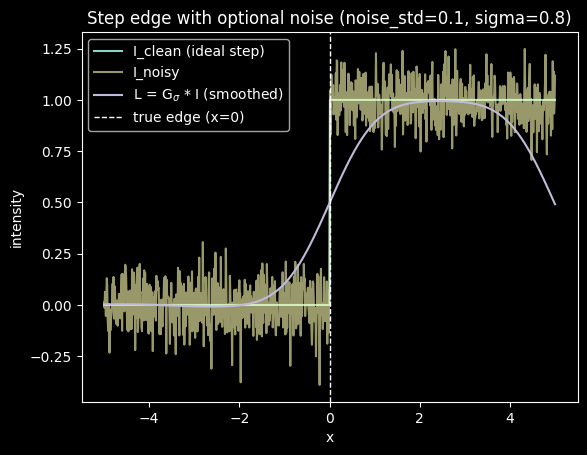

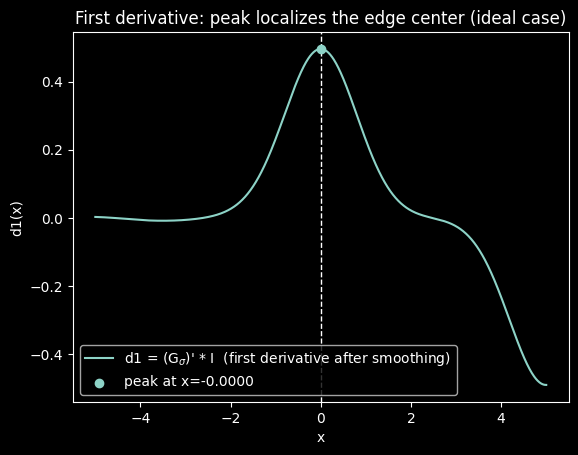

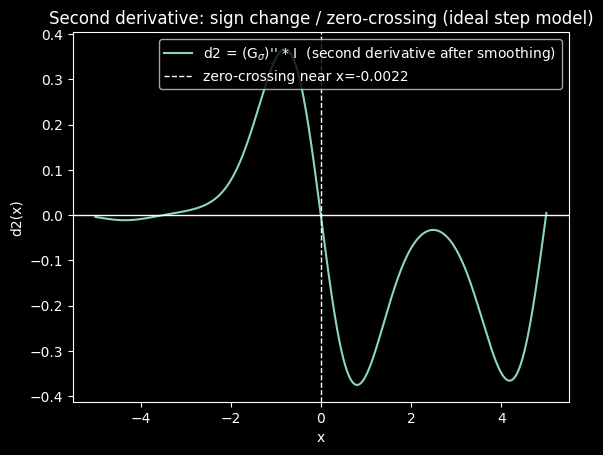

In [15]:
# Plot 1: clean vs noisy step and smoothed signal
plt.figure()
plt.plot(x, I_clean, label="I_clean (ideal step)")
plt.plot(x, I_noisy, label="I_noisy", alpha=0.6)
plt.plot(x, L, label=r"L = G$_\sigma$ * I (smoothed)")
plt.axvline(0.0, linestyle="--", linewidth=1, label="true edge (x=0)")
plt.title(f"Step edge with optional noise (noise_std={noise_std}, sigma={sigma})")
plt.xlabel("x")
plt.ylabel("intensity")
plt.legend()
plt.show()

# Plot 2: first derivative response and its peak
plt.figure()
plt.plot(x, d1, label=r"d1 = (G$_\sigma$)' * I  (first derivative after smoothing)")
plt.scatter([x_peak], [d1_peak], zorder=3, label=f"peak at x={x_peak:.4f}")
plt.axvline(x_peak, linestyle="--", linewidth=1)
plt.title("First derivative: peak localizes the edge center (ideal case)")
plt.xlabel("x")
plt.ylabel("d1(x)")
plt.legend()
plt.show()

# Plot 3: second derivative response and zero-crossing
plt.figure()
plt.plot(x, d2, label=r"d2 = (G$_\sigma$)'' * I  (second derivative after smoothing)")
plt.axhline(0.0, linewidth=1)
if x_zc is not None:
    plt.axvline(x_zc, linestyle="--", linewidth=1, label=f"zero-crossing near x={x_zc:.4f}")
plt.title("Second derivative: sign change / zero-crossing (ideal step model)")
plt.xlabel("x")
plt.ylabel("d2(x)")
plt.legend()
plt.show()